
# Итоговый проект: Рекомендательная система для электронной коммерции`

**Фокус бизнес-метрики:** *добавления в корзину (add-to-cart)* — как прокси целевого интереса.  
**Офлайн-метрики:** Recall@K / MAP@K / NDCG@K.  
**Модель:** ALS по неявной обратной связи + фоллбек на популярность и холодный старт по *recent_item_ids*.


## 1. Импорты и конфигурация


In [1]:

import os, json, yaml, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns
from src.pipeline.train import train_pipeline
from src.pipeline.utils import load_raw_data, basic_filters, downsample_users, temporal_split_per_user
from src.pipeline.utils import build_mappings, build_interaction_matrix, build_user_targets, popularity_top_items
from src.common.metrics import recall_at_k, map_at_k, ndcg_at_k

CONFIG_PATH = "config/config.yaml"
with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

pprint(cfg)


{'als': {'alpha': 40.0,
         'factors': 64,
         'filter_seen': True,
         'iterations': 20,
         'regularization': 0.01,
         'topk': 20,
         'use_bm25': True},
 'data': {'downsample_users': 0.0,
          'min_item_interactions': 5,
          'min_user_interactions': 3,
          'use_synthetic_if_missing': True},
 'mlflow': {'enabled': True,
            'experiment': 'ecomm-recsys',
            'tracking_uri': './mlruns'},
 'paths': {'artifacts_dir': 'artifacts',
           'models_dir': 'models',
           'processed_dir': 'data/processed',
           'raw_data_dir': 'data'},
 'search': {'enabled': True,
            'params': {'alpha': [20.0, 40.0],
                       'factors': [64, 128],
                       'iterations': [15, 20],
                       'regularization': [0.01, 0.05],
                       'use_bm25': [True, False]}},
 'seed': 42,
 'service': {'topk_default': 20},
 'split': {'test_last_n': 1, 'val_last_n': 1},
 'weights': {'addto


## 2. Загрузка данных


In [2]:

raw_dir = os.path.join(".", cfg["paths"]["raw_data_dir"])
events, props, cats = load_raw_data(raw_dir)

print("Events shape:", events.shape)
print("Head:")
print("Item properties:", props.shape, "Category tree:", cats.shape)


Events shape: (2756101, 5)
Head:
Item properties: (20275902, 4) Category tree: (1669, 2)



## 3. EDA 

In [3]:
print("category_tree")
display(cats.head())

print("\n events")
display(events.head())

print("\n item_properties")
display(props.head())

category_tree


,categoryid,parentid
0,1016,213.0
1,809,169.0
2,570,9.0
3,1691,885.0
4,536,1691.0



 events


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN



 item_properties


,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [4]:
print("category_tree info:")
display(cats.info())
print(cats.isna().sum())

print("\nevents info:")
display(events.info())
print(events.isna().sum())

print("\nitem_properties info:")
display(props.info())
print(props.isna().sum())

category_tree info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1669 entries, 0 to 1668
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   categoryid  1669 non-null   int64  
 1   parentid    1644 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 26.2 KB


None

categoryid     0
parentid      25
dtype: int64

events info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2756101 entries, 0 to 2756100
Data columns (total 5 columns):
 #   Column         Dtype  
---  ------         -----  
 0   timestamp      int64  
 1   visitorid      int64  
 2   event          object 
 3   itemid         int64  
 4   transactionid  float64
dtypes: float64(1), int64(3), object(1)
memory usage: 105.1+ MB


None

timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

item_properties info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20275902 entries, 0 to 20275901
Data columns (total 4 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  int64 
 1   itemid     int64 
 2   property   object
 3   value      object
dtypes: int64(2), object(2)
memory usage: 618.8+ MB


None

timestamp    0
itemid       0
property     0
value        0
dtype: int64


In [5]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")
props["timestamp"] = pd.to_datetime(props["timestamp"], unit="ms")


In [6]:
print("События:", events["event"].value_counts())
print("Уникальных пользователей:", events["visitorid"].nunique())
print("Уникальных товаров:", events["itemid"].nunique())
print("Уникальных транзакций:", events["transactionid"].nunique())


События: event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: int64
Уникальных пользователей: 1407580
Уникальных товаров: 235061
Уникальных транзакций: 17672


/tmp/ipykernel_47747/1899873006.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel.index, y=funnel.values, palette="viridis")


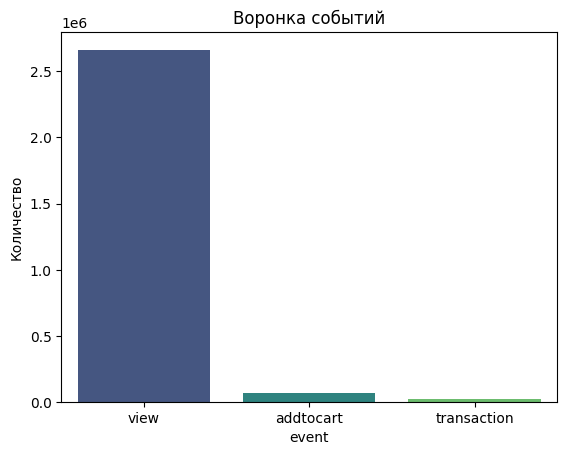

In [7]:
funnel = events["event"].value_counts()
sns.barplot(x=funnel.index, y=funnel.values, palette="viridis")
plt.title("Воронка событий")
plt.ylabel("Количество")
plt.show()


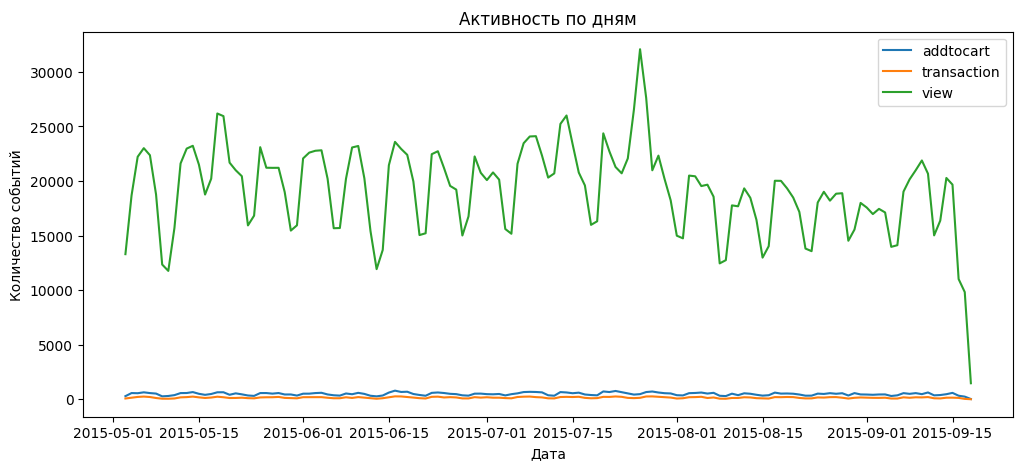

In [8]:
events["date"] = events["timestamp"].dt.date
by_day = events.groupby(["date", "event"])["visitorid"].count().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
for col in by_day.columns:
    plt.plot(by_day.index, by_day[col], label=col)
plt.legend()
plt.title("Активность по дням")
plt.xlabel("Дата")
plt.ylabel("Количество событий")
plt.show()


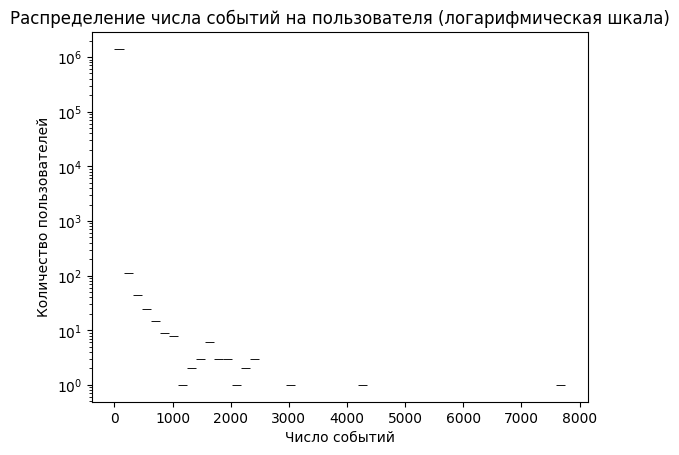

In [9]:
user_activity = events.groupby("visitorid")["event"].count()
sns.histplot(user_activity, bins=50, log_scale=(False, True))
plt.title("Распределение числа событий на пользователя (логарифмическая шкала)")
plt.xlabel("Число событий")
plt.ylabel("Количество пользователей")
plt.show()


In [10]:
print("Уникальных категорий (родителей):", cats["parentid"].nunique())
print("Уникальных категорий (детей):", cats["categoryid"].nunique())

display(cats.sample(10))


Уникальных категорий (родителей): 362
Уникальных категорий (детей): 1669


,categoryid,parentid
514,544,1168.0
1654,1095,409.0
1050,946,351.0
1099,960,594.0
426,1666,1684.0
529,438,312.0
1593,1622,1292.0
729,477,1596.0
535,0,605.0
112,1414,854.0


Уникальных товаров с описанием: 417053
Уникальных свойств: 1104


/tmp/ipykernel_47747/2244126967.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_props.index, x=top_props.values, palette="mako")


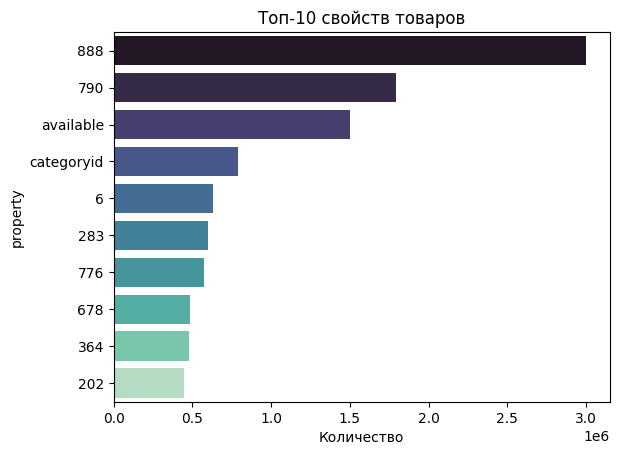

In [11]:
print("Уникальных товаров с описанием:", props["itemid"].nunique())
print("Уникальных свойств:", props["property"].nunique())

# Топ-10 свойств
top_props = props["property"].value_counts().head(10)
sns.barplot(y=top_props.index, x=top_props.values, palette="mako")
plt.title("Топ-10 свойств товаров")
plt.xlabel("Количество")
plt.show()


#### Выводы

Фильтры пользователей: большинство пользователей совершают только просмотры → потенциально стоит выделить активных покупателей отдельно.

Конверсия: большая потеря на пути от просмотра к корзине и дальше к покупке. Можно анализировать факторы отказа.

Сезонность: активность снижается к концу выборки — возможно, это связано с маркетинговыми кампаниями или спадом интереса.

Категории: большое количество категорий (1669) — есть смысл укрупнять для анализа, чтобы избежать переобучения моделей.

Свойства товаров: dataset богат атрибутами (1104 свойства), можно использовать для построения рекомендательных моделей.


## 4. Подготовка данных для моделирования
Фильтрация редких пользователей/товаров и, при необходимости, даунсемплинг для ускорения.


In [12]:

events_f = basic_filters(events, min_user_inter=cfg["data"]["min_user_interactions"],
                         min_item_inter=cfg["data"]["min_item_interactions"])
events_f = downsample_users(events_f, frac=cfg["data"]["downsample_users"], seed=cfg["seed"])
print("After filtering:", events_f.shape)


After filtering: (1188099, 6)



## 5. Сплит по времени: train/val/test


In [13]:

splitted = temporal_split_per_user(events_f, val_last_n=cfg["split"]["val_last_n"], test_last_n=cfg["split"]["test_last_n"])
train_df = splitted[splitted["split"]=="train"].copy()
val_df = splitted[splitted["split"]=="val"].copy()
test_df = splitted[splitted["split"]=="test"].copy()

print(train_df.shape, val_df.shape, test_df.shape)
display(train_df.head())


(854855, 7) (166622, 7) (166622, 7)


,timestamp,visitorid,event,itemid,transactionid,date,split
1361687,2015-09-11 20:49:49.439,0,view,285930,NaN,2015-09-11,train
742616,2015-08-07 17:51:44.567,2,view,325215,NaN,2015-08-07,train
735273,2015-08-07 17:53:33.790,2,view,325215,NaN,2015-08-07,train
737711,2015-08-07 17:56:52.664,2,view,259884,NaN,2015-08-07,train
726292,2015-08-07 18:01:08.920,2,view,216305,NaN,2015-08-07,train



## 6. Матрица взаимодействий и таргеты


In [14]:

user2idx, idx2user, item2idx, idx2item = build_mappings(train_df)
weights = cfg["weights"]
train_mat = build_interaction_matrix(train_df, user2idx, item2idx, weights)
val_targets = build_user_targets(val_df, item2idx)
test_targets = build_user_targets(test_df, item2idx)

print("Matrix shape:", train_mat.shape, "Val users:", len(val_targets), "Test users:", len(test_targets))


Matrix shape: (190804, 49819) Val users: 166622 Test users: 166622



## 7. Быстрый бейзлайн: популярность


In [15]:

popular_items = popularity_top_items(train_df, topk=1000)
popular_item_idxs = [item2idx[it] for it in popular_items if it in item2idx]

# Предсказания для валидации — просто топ популярных
preds_pop = [popular_item_idxs[:cfg["als"]["topk"]] for _ in range(len(val_targets))]
tgts = list(val_targets.values())

for k in [5,10,20]:
    r = recall_at_k(preds_pop, tgts, k)
    m = map_at_k(preds_pop, tgts, k)
    n = ndcg_at_k(preds_pop, tgts, k)
    print(f"[Popularity] k={k}: recall={r:.4f} map={m:.4f} ndcg={n:.4f}")


[Popularity] k=5: recall=0.0040 map=0.0024 ndcg=0.0028
[Popularity] k=10: recall=0.0065 map=0.0027 ndcg=0.0036
[Popularity] k=20: recall=0.0136 map=0.0032 ndcg=0.0054



## 8. Обучение ALS + оценка на валидации


In [16]:

result = train_pipeline(cfg)
print("ALS metrics:")
print(json.dumps(result["metrics"], indent=2, ensure_ascii=False))


/home/mle-user/mle-pr-final/.vend_dnslfin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle-pr-final/.vend_dnslfin/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:13<00:00,  1.48it/s]


ALS metrics:
{
  "recall@5": 0.08439094674911449,
  "map@5": 0.04673082386079469,
  "ndcg@5": 0.05603278251252553,
  "recall@10": 0.11978747673650718,
  "map@10": 0.05138402329919657,
  "ndcg@10": 0.06740588535249363,
  "recall@20": 0.16314462388185147,
  "map@20": 0.0543769041038193,
  "ndcg@20": 0.07834617020874608
}


In [17]:
import mlflow


TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000


mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

EXPERIMENT_NAME = cfg.get("mlflow", {}).get("experiment", "ecomm-recsys")
RUN_NAME = "baseline"
REGISTRY_MODEL_NAME = "model_ecomm-recsys"

In [18]:
import json, os, numpy as np
from src.pipeline.train import load_model_for_serving

model_dir = cfg["paths"]["models_dir"]
model = load_model_for_serving(model_dir)


In [19]:
model_dir

'models'

In [20]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if not experiment:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    mlflow.log_params({
        "als_factors": cfg['als']['factors'],
        "als_reg": cfg['als']['regularization'],
        "als_iter": cfg['als']['iterations'],
        "als_alpha": cfg['als']['alpha'],
        "als_bm25": cfg['als']['use_bm25']
    })
    mlflow.log_metrics({k.replace("@", "_"): v for k, v in result["metrics"].items()})
    mlflow.log_artifacts('models')

🏃 View run baseline at: http://127.0.0.1:5000/#/experiments/21/runs/0be420f9e4524b9d8ad9239bab2f860a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/21
